# Лабораторная работа 2. Визуализация данных

**Вариант 5.** Набор данных `visits.csv` — Данные пользовательских сессий магазина

**Цель работы:** осуществить разведочный анализ данных с помощью
различных методов визуализации.


In [ ]:
import pandas as pd

url = 'https://raw.githubusercontent.com/versanivc/LR/refs/heads/main/visits.csv'

# Чтение таблицы с разделителем ;
df = pd.read_csv(url, sep=';')

## 2. Вывод первых 20 строк

С помощью метода `head()` выводим первые 20 строк набора данных, чтобы составить общее впечатление о данных.

In [ ]:
# Вывод первых 20 строк
df.head(20)

,User_Id,Region,Device,Channel,Session_Start,SESSION_End
0,"9,81449E+11",United States,iPhone,organic,01.05.2019 2:36,01.05.2019 2:45
1,"2,78966E+11",United States,iPhone,organic,01.05.2019 4:46,01.05.2019 4:47
2,"5,90706E+11",United States,Mac,organic,01.05.2019 14:09,01.05.2019 15:32
3,"3,26434E+11",United States,Android,TipTop,01.05.2019 0:29,01.05.2019 0:54
4,"3,49774E+11",United States,Mac,organic,01.05.2019 3:33,01.05.2019 3:57
5,43958116050,United States,Android,organic,01.05.2019 9:03,01.05.2019 10:08
6,"1,85365E+11",United States,iPhone,organic,01.05.2019 9:37,01.05.2019 10:00
7,"1,00971E+11",United States,Mac,TipTop,01.05.2019 4:39,01.05.2019 4:57
8,"3,70456E+11",United States,iPhone,organic,01.05.2019 14:44,01.05.2019 15:41
9,"1,41838E+11",United States,Mac,FaceBoom,01.05.2019 6:20,01.05.2019 6:54


## 3. Обзор данных - описание столбцов и предметной области

Набор данных содержит информацию о пользовательских сессии магазина. Описание столбцов:

- **User_Id** - уникальный идентификатор пользователя
- **Region** -  страна пользователя
- **Device** -  устройство пользователя
- **Channel** - идентификатор рекламного источника, из которого пришел
пользователь
- **Session_Start** - дата и время начала сессии
- **SESSION_End** - дата и время окончания сессии


Предметная область — электронная коммерция. Данные могут использоваться для анализа поведения пользователей, продолжительности сессий, эффективности рекламных каналов, а также различий в активности пользователей в зависимости от региона и типа устройства.

## 4. Оценка данных с помощью info()

Метод `info()` предоставляет общую информацию о таблице: названия столбцов, типы данных, хранящиеся в них, и количество ненулевых значений в каждом столбце.

In [ ]:
# Общая информация о таблице
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 957 entries, 0 to 956
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   User_Id        957 non-null    object
 1   Region         956 non-null    object
 2   Device         955 non-null    object
 3   Channel        957 non-null    object
 4   Session_Start  955 non-null    object
 5   SESSION_End    955 non-null    object
dtypes: object(6)
memory usage: 45.0+ KB


**Результаты:**
- Всего строк: 957
- Столбцов: 6
- Обнаружены пропуски в столбцах: `Region` (1), `Device` (2), `Session_Start` (2), `SESSION_End` (2),
- Без пропусков: `User_Id`, `Channel`
- Типы данных: `object` (6)

**Проблемы:**
- `Session_Start` определён как `object` вместо даты и времени
- `SESSION_End` определён как `object` вместо даты и времени
- `SESSION_End` записан в верхнем регистре, в отличие от `Session_End`
- Наличие пропусков требует обработки


## 5. Применение describe()

С помощью `describe()` оценим числовые столбцы: посмотрим на средние значения, минимум, максимум, стандартное отклонение и квартили.

In [ ]:
# Статистика по числовым столбцам
df.describe()

,User_Id,Region,Device,Channel,Session_Start,SESSION_End
count,957,956,955,957,955,955
unique,865,2,6,4,820,836
top,"1,79085E+11",United States,iPhone,organic,02.05.2019 9:40,02.05.2019 22:49
freq,4,955,421,612,4,3


С помощью `describe()` оценены числовые столбцы:

- **User_Id:** всего 957 записей, из них 865 уникальных пользователей. Некоторые пользователи посещали сайт несколько раз.
- **Region:** пользователи представлены из 2 стран, при этом почти все записи относятся к United States.
- **Device:** в данных присутствует 6 типов устройств. Наиболее популярное устройство — iPhone, встречается 421 раз.
- **Channel:** используется 4 рекламных канала. Чаще всего пользователи приходят через канал organic — 612 сессий.
- **Session_Start:** зафиксировано 820 уникальных моментов начала сессий, некоторые даты и время повторяются.
- **SESSION_End:** присутствует 836 уникальных значений времени окончания сессий.

## 6. Проверка названий столбцов

Выведем названия столбцов с помощью `df.columns` и проверим, есть ли проблемы: пробелы в названиях, разные языки, непонятные названия.

In [ ]:
# Вывод названий столбцов
print(df.columns.tolist())

['User_Id', 'Region', 'Device', 'Channel', 'Session_Start', 'SESSION_End']


Как видно выше, названия столбцов в целом оформлены корректно: отсутствуют пробелы, большинство столбцов придерживаются единого стиля именования. Однако наблюдается небольшое несоответствие — столбец SESSION_End записан в верхнем регистре, в отличие от остальных названий. После приведения к единому стилю он был приведён к виду Session_End.

In [ ]:
# Переименование отдельных столбцов
df = df.rename(columns={'SESSION_End': 'Session_End'})

# Вывод названий столбцов
print(df.columns.tolist())


['User_Id', 'Region', 'Device', 'Channel', 'Session_Start', 'Session_End']


С помощью метода `rename()` столбец `SESSION_End` был переименован в `Session_End`. Теперь названия столбцов приведены к единому стилю: отсутствуют пробелы, имена оформлены в согласованном формате, а также являются понятными и отражают суть данных.

## 7. Проверка данных на наличие пропусков

Для нахождения пропусков применяется метод `isna()`. Потом результат работы `isna()` передаём методу `sum()`.

In [ ]:
# Подсчёт количества пропусков в каждом столбце
print(df.isna().sum())

User_Id          0
Region           1
Device           2
Channel          0
Session_Start    2
Session_End      2
dtype: int64


В результате проверки обнаружены пропуски в 4 столбцах:
- `Region` - 1 пропуск
- `Device` - 2 пропуска
- `Session_Start` - 2 пропуска
- `Session_End ` - 2 пропуска

Способ обработки пропусков зависит от их типа и значимости столбца:
- Строки без данных в столбцах  (`Session_Start` и `Session_End`) удалены, так как без этой информации запись теряет смысл.
- Пропуски в столбцах (`Region` и `Device`) заполним пропущенные значения наиболее часто встречающимися значениями в таблице. - это позволяет сохранить строки и не исказить общее распределение значений.


In [ ]:
# 1. Удаляем строки, где пропущено начало и конец сессии
df = df.dropna(subset=['Session_Start'])
df = df.dropna(subset=['Session_End'])
# 2. Заполняем столбцы  Регион и Столбец наиболее часто
# встречающимися значениями в таблице
df['Region'] = df['Region'].fillna(df['Region'].mode()[0])
df['Device'] = df['Device'].fillna(df['Device'].mode()[0])


# 4. Проверяем, что пропусков не осталось
print(df.isna().sum())

User_Id          0
Region           0
Device           0
Channel          0
Session_Start    0
Session_End      0
dtype: int64


Пропуски успешно обработаны. Во всех столбцах количество пропусков - 0. Данные готовы к дальнейшей проверке.

## 8. Проверка данных на наличие дубликатов

Проверим явные и неявные дубликаты. Для поиска явных дубликатов используется метод `duplicated()`.

In [ ]:
# Поиск и подсчёт явных дубликатов
print('Количество дубликатов:', df.duplicated().sum())

# Вывод строк-дубликатов
print('\nСтроки-дубликаты:')
display(df[df.duplicated()])

# Удаление дубликатов и обновление индексации
df = df.drop_duplicates().reset_index(drop=True)

# Проверяем, что дубликатов не осталось
print('\nКоличество дубликатов после удаления:', df.duplicated().sum())

Количество дубликатов: 2

Строки-дубликаты:


,User_Id,Region,Device,Channel,Session_Start,Session_End
480,"1,79085E+11",United States,Mac,organic,01.05.2019 7:27,01.05.2019 7:49
481,"1,79085E+11",United States,Mac,organic,01.05.2019 7:27,01.05.2019 7:49



Количество дубликатов после удаления: 0


Для поиска неявных дубликатов — смотрим уникальные значения в текстовых столбцах

In [ ]:
# Поиск неявных дубликатов: смотрим уникальные значения в  столбцах
print('Уникальные значения в столбце "Region":')
print(df['Region'].unique())

print('\nУникальные значения в столбце "Device":')
print(df['Device'].unique())

print('\nУникальные значения в столбце "Channel":')
print(df['Channel'].unique())

Уникальные значения в столбце "Region":
['United States' 'USA']

Уникальные значения в столбце "Device":
['iPhone' 'Mac' 'Android' 'PC' 'MAC' 'IPHONE']

Уникальные значения в столбце "Channel":
['organic' 'TipTop' 'FaceBoom' 'MediaTornado']


Приведено приведение значений столбцов `Region` и `Device` к единому формату с использованием функции `replace()`

In [ ]:

# Приводим значения столбца Region к единому формату:
# заменяем сокращение 'USA' на полное название 'United States'
df['Region'] = df['Region'].replace('USA', 'United States')
# Приводим значения столбца Device к единому стилю написания:
# заменяем некорректные/разные варианты названий устройств на стандартные
df['Device'] = df['Device'].replace({
'MAC': 'Mac','IPHONE': 'iPhone'})
# Проверяем
print(df['Region'].unique())
print(df['Device'].unique())

['United States']
['iPhone' 'Mac' 'Android' 'PC']


**Явные дубликаты.** С помощью метода `duplicated()` было обнаружено 2 повторяющиеся строки (один пользователь с одной датой начала сессии — 01.05.2019 7:27 — встречается дважды). Дубликаты были удалены с помощью метода `drop_duplicates()` с обновлением индексации.

**Неявные дубликаты.** С помощью метода `unique()` в столбцах `Region` и `Device` были выявлены несогласованные записи. В столбце `Region` сокращение `USA` было заменено на полное название `United States` с помощью метода `replace()`. В столбце `Device` значения `MAC` и `IPHONE` были приведены к единому формату (`Mac` и `iPhone` соответственно) также с использованием `replace()`.

После преобразований проверка методом `unique()` показала, что значения стандартизированы. В столбце `Channel` неявных дубликатов обнаружено не было.

## 9. Проверка типов данных

Проверим типы данных в столбцах и при необходимости изменим их, чтобы они соответствовали действительности.

In [ ]:
# Проверка текущих типов данных
print(df.dtypes)

User_Id          object
Region           object
Device           object
Channel          object
Session_Start    object
Session_End      object
dtype: object


Столбцы `Session_Start` и `Session_End` имеют тип `object`, хотя должны быть в формат даты и времени (datetime)

In [ ]:
# Приведение к формату даты и времени
df['Session_Start'] = pd.to_datetime(df['Session_Start'], format='%d.%m.%Y %H:%M')
df['Session_End'] = pd.to_datetime(df['Session_End'], format='%d.%m.%Y %H:%M')
# Проверяем результат
print(df.dtypes)

User_Id                  object
Region                   object
Device                   object
Channel                  object
Session_Start    datetime64[ns]
Session_End      datetime64[ns]
dtype: object


## 10. Выводы по работе

По итогам выполнения контрольной работы был проведён полный цикл предварительного анализа и очистки набора данных `visits.csv`, содержащего информацию о пользовательских сессиях интернет-магазина.

В процессе работы были последовательно решены следующие задачи: загрузка данных с корректным указанием разделителя, первичный визуальный осмотр первых 20 строк, анализ структуры таблицы с помощью `info()` и `describe()`. В ходе анализа выявлены и устранены типичные проблемы исходных данных: некорректные типы данных в столбцах с датой и временем, пропуски значений в столбцах `Region`, `Device`, `Session_Start`, `Session_End`, явные дубликаты строк, а также неявные дубликаты, связанные с несогласованным написанием значений в категориальных переменных (`USA / United States`, `MAC / Mac`, `IPHONE / iPhone`). Дополнительно приведено к единому стилю название столбца `SESSION_End`.

Для обработки пропусков использовались удаление строк с критическими пропусками и заполнение модальными значениями. Дубликаты удалены, а категориальные переменные стандартизированы. Типы данных столбцов `Session_Start` и `Session_End` успешно преобразованы в формат `datetime`.

В результате получен очищенный, структурированный и готовый к дальнейшему анализу набор данных, что подтверждает достижение цели работы и освоение ключевых методов предобработки данных с использованием библиотеки pandas.

##**Визуализация данных**

In [ ]:
df['Session_duration'] = df['Session_End'] - df['Session_Start']
print(df)

         User_Id         Region   Device   Channel       Session_Start  \
0    9,81449E+11  United States   iPhone   organic 2019-05-01 02:36:00   
1    2,78966E+11  United States   iPhone   organic 2019-05-01 04:46:00   
2    5,90706E+11  United States      Mac   organic 2019-05-01 14:09:00   
3    3,26434E+11  United States  Android    TipTop 2019-05-01 00:29:00   
4    3,49774E+11  United States      Mac   organic 2019-05-01 03:33:00   
..           ...            ...      ...       ...                 ...   
948  5,55066E+11  United States   iPhone    TipTop 2019-05-04 23:32:00   
949  7,71716E+11  United States  Android    TipTop 2019-05-04 19:32:00   
950  74352279110  United States   iPhone    TipTop 2019-05-04 00:13:00   
951  6,08683E+11  United States  Android  FaceBoom 2019-05-04 03:33:00   
952  8,75326E+11  United States      Mac   organic 2019-05-04 03:01:00   

            Session_End Session_duration  
0   2019-05-01 02:45:00  0 days 00:09:00  
1   2019-05-01 04:47:00  

##Задание 1: Постройте гистограмму распределения для любого столбца. Сделайте минимум 3 гистограммы.


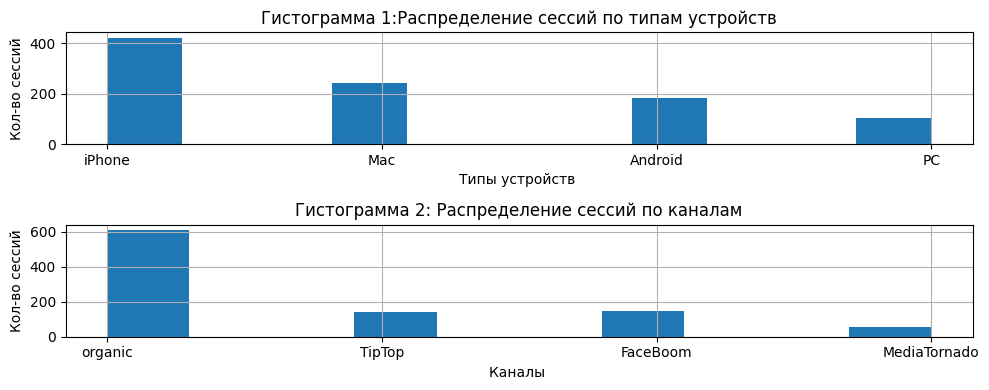

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(
 2, # одна строка
 1, # столбец
 figsize=(10, 4) # размер графика
)
#График 1
df['Device'].hist(bins=11, ax = axes[0]) # построение гистограм-мы
axes[0].set_ylabel("Кол-во сессий"); # подпись к оси y
axes[0].set_xlabel("Типы устройств "); # подпись к оси x
axes[0].set_title('Гистограмма 1:Распределение сессий по типам устройств')
plt.tight_layout()  #отступ

#График 2
df['Channel'].hist(bins=10, ax = axes[1]) # построение гистограм-мы
axes[1].set_ylabel("Кол-во сессий"); # подпись к оси y
axes[1].set_xlabel("Каналы "); # подпись к оси x
axes[1].set_title('Гистограмма 2: Распределение сессий по каналам')
plt.tight_layout()  #отступ



На гистограмме 1 представлена диаграмма, которая показывает количество сессий по каждому устройству. Как видно из графика, `iPhone` занимает первое место, а `PC` — последнее

По графику 2 распределение сессий по каналам показывает, что наиболее популярным каналом является `organic`, а наименее популярным — `MediaTornado`.


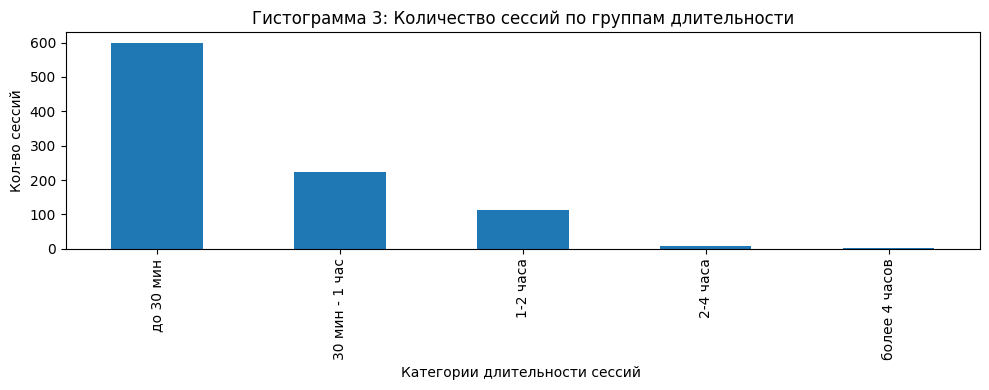

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(
 1, # одна строка
 1, # столбеец
 figsize=(10, 4) # размер графика
)

#График 3
df['duration_minutes'] = df['Session_duration'].dt.total_seconds() / 60
# Создаем категории
bins = [0, 30, 60, 120, 240, float('inf')]
labels = ['до 30 мин', '30 мин - 1 час', '1-2 часа', '2-4 часа', 'более 4 часов']

df['duration_group'] = pd.cut(df['duration_minutes'], bins=bins, labels=labels)
df['duration_group'].value_counts().sort_index().plot.bar(ax=axes)
axes.set_ylabel("Кол-во сессий"); # подпись к оси y
axes.set_xlabel("Категории длительности сессий "); # подпись к оси x
axes.set_title('Гистограмма 3: Количество сессий по группам длительности')
plt.tight_layout()  #отступ

На графике 3 видно, что больше всего сессий имеют длительность до 30 минут. На втором месте — сессии длительностью от 30 минут до 1 часа. И, как видим, сессий продолжительностью более 4 часов почти нет.

##Задание 2 : Постройте диаграмму размаха (boxplot) для любого столбца. Сделайте минимум 2 диаграммы размаха. Используйте разные библиотеки.

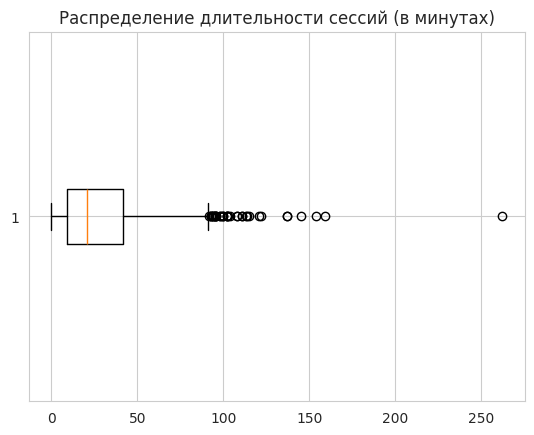

In [93]:
import matplotlib.pyplot as plt

plt.boxplot(df['duration_minutes'], vert=False)
plt.title('Распределение длительности сессий (в минутах)')
plt.show()

На графике представлено распределение длительности пользовательских сессий в минутах, визуализированное в формате box-plot. Данные демонстрируют выраженную правостороннюю асимметрию: основная концентрация наблюдений приходится на короткие сессии. `Медианное` значение составляет приблизительно 22 минуты, а `межквартильный размах` (от 25-го до 75-го перцентиля) охватывает интервал 12–42 минуты, что характеризует типичную продолжительность активности для половины пользователей. `Верхняя граница` «уса» достигает отметки ~95 минут, после чего начинаются `статистические выбросы`. В диапазоне 90–110 минут фиксируется скопление `аномально длительных сессий`, за которым следуют единичные значения, превышающие 150 и 260 минут.

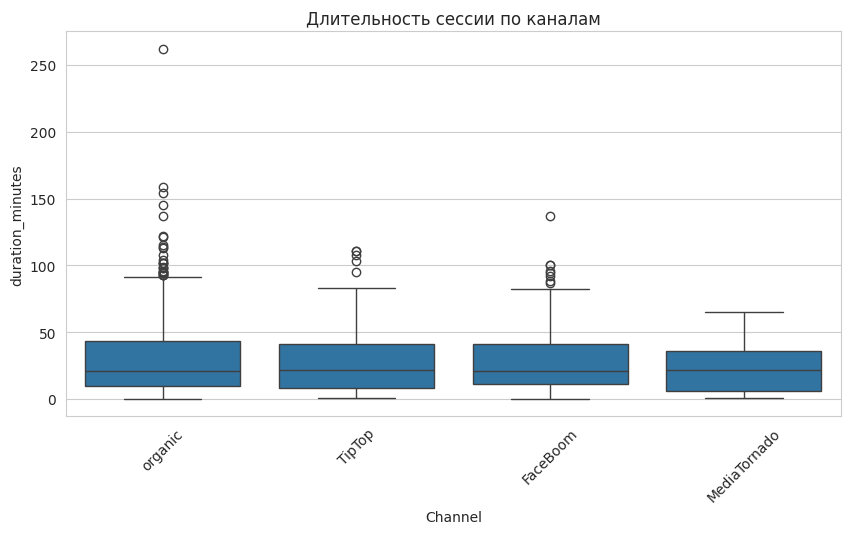

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(10,5))
sns.boxplot(x='Channel', y='duration_minutes', data=df)

plt.title('Длительность сессии по каналам')
plt.xticks(rotation=45)
plt.show()

Все четыре канала демонстрируют схожие медианные значения длительности сессий (приблизительно 20-30 минут), что видно по положению `медианны`
`Межквартильные диапазоны`  также имеют сопоставимую ширину по всем каналам, охватывая приблизительно интервал от 10–15 до 40–45 минут.

**Выбросы:** `organic` выделяется
наибольшим количеством и размахом экстремальных значений: присутствуют множественные выбросы в диапазоне 100-170 минут, а также один экстремальный выброс выше 250 минут
* `TipTop` и `faceboom` демонстрируют умеренное количество выбросов (до 110-140 минут)
* `MediaRomaNA` показывает наиболее "чистое" распределение с минимальным количеством выбросов (максимум около 65-70 минут)


 Каналы трафика не демонстрируют существенных различий по типичной продолжительности сессий, однако канал `organic` характеризуется наибольшей вариабельностью и наличием сверхдлительных сессий, что может указывать на неоднородность аудитории или специфику контента данного канала.

##Задание 3 : Оценить наличие выбросов по гистограммам и boxplot. Обработайте выбросы при необходимости и постройте графики заново.


Межквартильный размах= 33.0
Нижняя граница выбросов= -40.5
Верхняя граница выбросов= 91.5


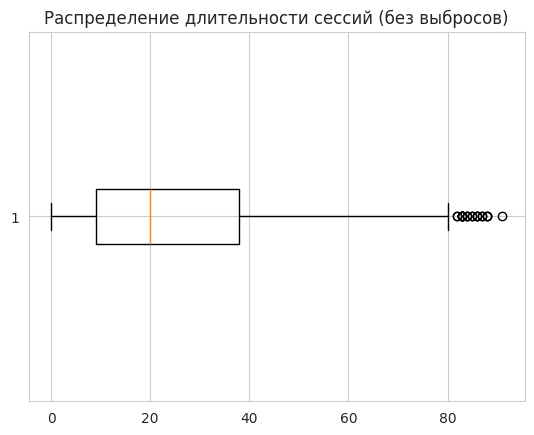

In [101]:
#Считаем границы
Q1 = df['duration_minutes'].quantile(0.25)
Q3 = df['duration_minutes'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Межквартильный размах=",IQR)
print("Нижняя граница выбросов=",lower_bound)
print("Верхняя граница выбросов=",upper_bound)
#Убираем выбросы
df_clean = df[
    (df['duration_minutes'] >= lower_bound) &
    (df['duration_minutes'] <= upper_bound)
]

import matplotlib.pyplot as plt

plt.boxplot(df_clean['duration_minutes'], vert=False)
plt.title('Распределение длительности сессий (без выбросов)')
plt.show()

Данные были очищены от выбросов с помощью метода `межквартильного размаха`. Значения выше 91,5 минуты были исключены, так как считались аномально большими.

После очистки основные показатели почти не изменились:`медиана` составляет примерно 20–22 минуты, а `межквартильный размах` — около 33 минут. Половина всех сессий находится в диапазоне от 10 до 43 минут.

Удаление очень длинных сессий (92–260 минут) не повлияло на общую картину данных, но убрало сильное смещение вправо и сделало распределение более корректным для анализа типичного поведения пользователей.

Межквартильный размах= 33.0
Нижняя граница выбросов= -40.5
Верхняя граница выбросов= 91.5


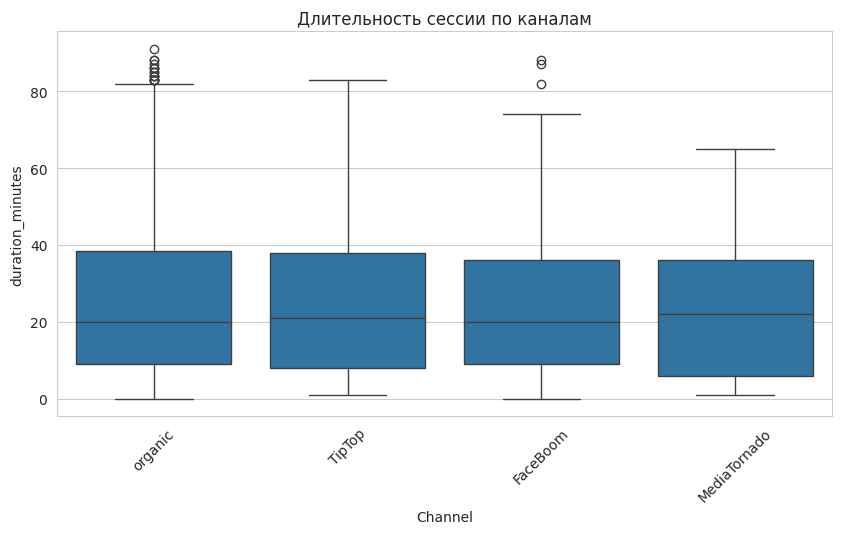

In [103]:
#Считаем границы
Q1 = df['duration_minutes'].quantile(0.25)
Q3 = df['duration_minutes'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Межквартильный размах=",IQR)
print("Нижняя граница выбросов=",lower_bound)
print("Верхняя граница выбросов=",upper_bound)
#Убираем выбросы
df_clean = df[
    (df['duration_minutes'] >= lower_bound) &
    (df['duration_minutes'] <= upper_bound)
]

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(10,5))
sns.boxplot(x='Channel', y='duration_minutes', data=df_clean)

plt.title('Длительность сессии по каналам')
plt.xticks(rotation=45)
plt.show()

После удаления значений выше 91,5 минуты график стал более компактным и информативным: основная часть данных теперь хорошо различима, а влияние экстремальных значений исчезло.

Ранее в канале `organic` наблюдались очень длинные сессии (свыше 100 и даже 260 минут), которые искажали общую картину. После очистки видно, что распределения по всем каналам стали схожими.

`Медианные значения` длительности сессий у всех источников находятся примерно в диапазоне 20–25 минут, а разброс средних 50% наблюдений также сопоставим. При этом `MediaTornado` выглядит наиболее стабильным каналом и не содержит выбросов.

В целом удаление аномалий не изменило общие выводы, но сделало сравнение каналов более точным и удобным для анализа.

##Задание 4 : Построить диаграмму размаха (boxplot) для любого числового столбца по разным категориям. Например, boxplot зарплаты по типу работы.



Межквартильный размах= 33.0
Нижняя граница выбросов= -40.5
Верхняя граница выбросов= 91.5


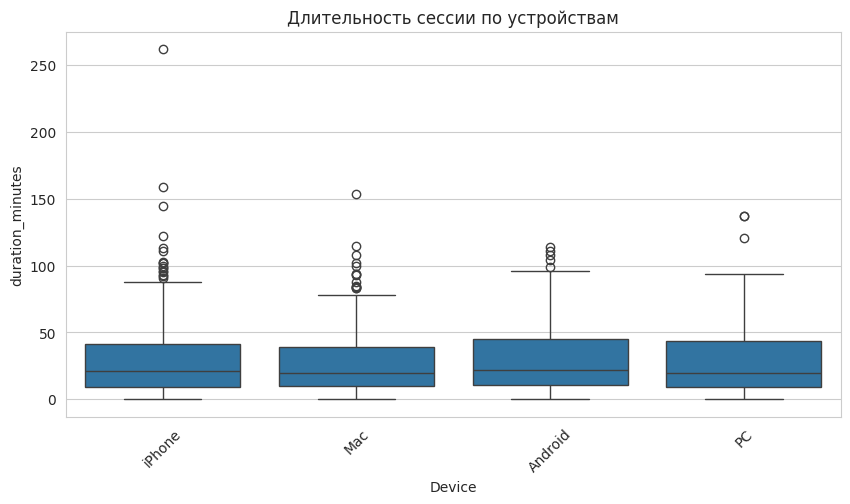

In [111]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(10,5))
sns.boxplot(x='Device', y='duration_minutes', data=df)

plt.title('Длительность сессии по устройствам')
plt.xticks(rotation=45)
plt.show()

На графике показано распределение длительности сессий по устройствам: `iPhone`, `Mac`, `Android` и `PC`. Несмотря на подпись, указывающую на каналы, данные фактически сгруппированы по типам устройств.

Распределения во всех четырёх группах выглядят очень похожими. `Медианные значения` длительности сессий находятся примерно в диапазоне 20–25 минут для каждого устройства.

`Межквартильный размах` также сопоставим: основная часть значений лежит примерно в пределах 10–45(50) минут, что говорит о схожем поведении пользователей на разных платформах.

Во всех группах присутствуют выбросы — очень длинные сессии. Самое большое значение наблюдается на `iPhone` (более 250 минут), у `Mac` и `PC` — до 140–150 минут, у `Android` — около 110–120 минут.

В целом заметной разницы в длительности сессий между устройствами не наблюдается.

Межквартильный размах= 33.0
Нижняя граница выбросов= -40.5
Верхняя граница выбросов= 91.5


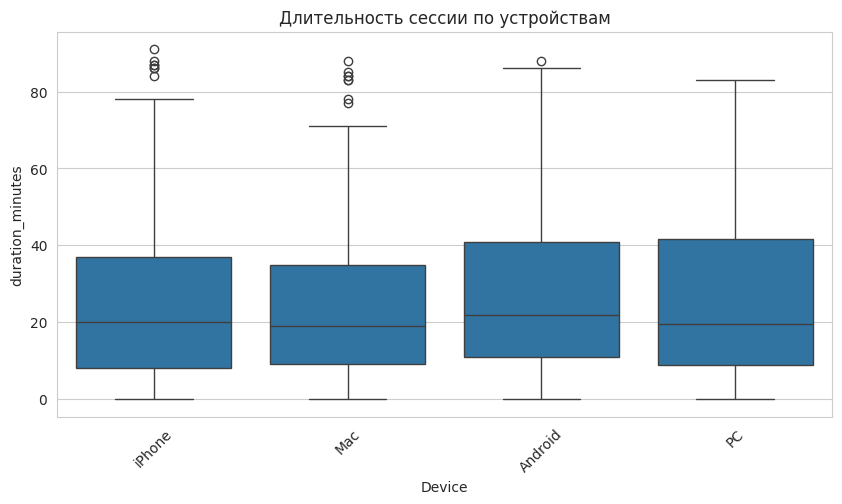

In [110]:
#Считаем границы
Q1 = df['duration_minutes'].quantile(0.25)
Q3 = df['duration_minutes'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Межквартильный размах=",IQR)
print("Нижняя граница выбросов=",lower_bound)
print("Верхняя граница выбросов=",upper_bound)
#Убираем выбросы
df_clean = df[
    (df['duration_minutes'] >= lower_bound) &
    (df['duration_minutes'] <= upper_bound)
]

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(10,5))
sns.boxplot(x='Device', y='duration_minutes', data=df_clean)

plt.title('Длительность сессии по устройствам')
plt.xticks(rotation=45)
plt.show()

После удаления выбросов стали заметнее различия между устройствами, которые раньше скрывались масштабом графика.

Наименьшая медианная длительность сессий у пользователей
* `Mac` — около 19 минут, что указывает на более низкую вовлечённость по сравнению с другими устройствами.
* У `PC` после очистки отсутствуют выбросы, но при этом наблюдается самый широкий межквартильный размах, что говорит о большой вариативности поведения пользователей.
* `Android` показывает самую высокую медиану — примерно 22 минуты, а также достаточно широкий разброс значений.
* `iPhone` выглядит наиболее сбалансированно: медиана находится на среднем уровне, а разброс значений умеренный.

В целом очистка данных позволила лучше увидеть реальные различия в поведении пользователей: от более коротких сессий на `Mac` до более разнообразного поведения на `PC` и `Android`.

##Задание 5 : Постройте матрицу диаграмм рассеивания. Можно добавить категории цветом

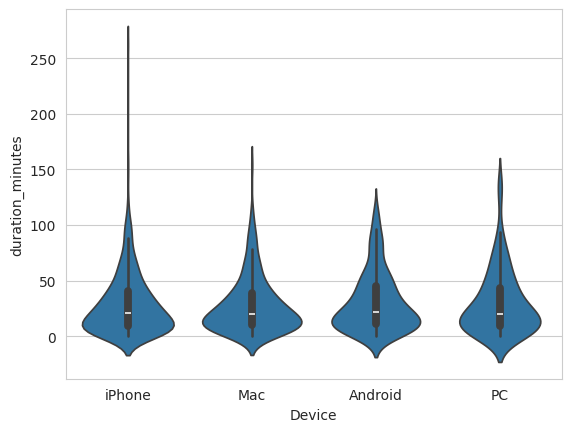

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.violinplot( x='Device', y='duration_minutes', data=df)

plt.show()


Во всех группах наблюдается выраженная правосторонняя асимметрия: основная масса значений сосредоточена до 50 минут, что говорит о преобладании коротких сессий. Дальше плотность резко снижается, формируя длинные хвосты, связанные с редкими очень продолжительными сессиями.

Сильнее всего это проявляется у `iPhone` — у него самый длинный хвост, уходящий за 270 минут, что указывает на наибольшую вариативность поведения пользователей.

У `Mac` распределение более узкое и с более низкой медианой. `Android` выглядит наиболее компактно по форме распределения и имеет менее выраженные экстремальные значения. `PC` занимает промежуточное положение по разбросу и форме плотности.

При этом медианные значения у всех устройств остаются близкими — примерно в диапазоне 20–25 минут, что говорит о схожей типичной длительности сессий.

В целом различия между устройствами проявляются не столько в «обычном» поведении пользователей, сколько в количестве и масштабе редких длинных сессий, особенно на устройствах `Apple`.

##Задание 6 : Постройте тепловую карту корреляции. Выполнить интерпретацию результатов корреляции, отвечая на вопросы о наличии (отсутствии) линейной взаимосвязи между переменными.

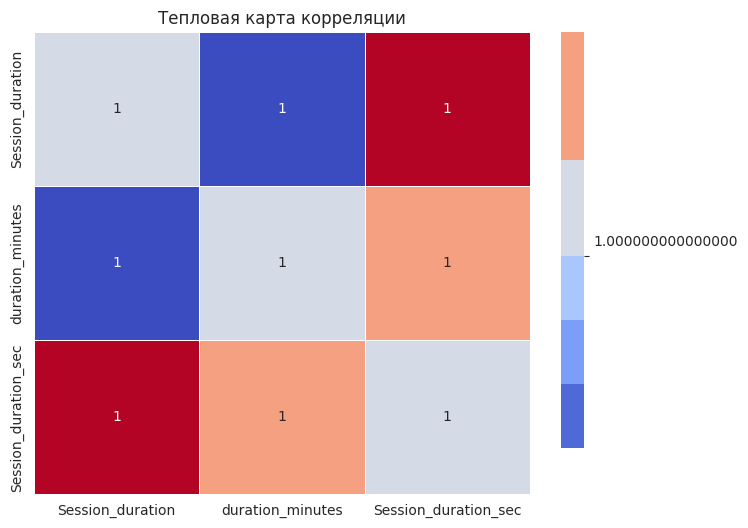

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt

# только числовые данные
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title('Тепловая карта корреляции')
plt.show()

На тепловой карте показаны связи между тремя метриками длительности сессий.

Диагональ матрицы выделена нейтральным серым цветом и отражает самокорреляцию переменных.

Наиболее сильная обратная зависимость наблюдается между `Session_duration` и `duration_minutes` — это видно по тёмно-синему цвету, который указывает на противоположное изменение показателей.

Максимальная положительная корреляция фиксируется между `Session_duration` и `Session_duration_sec` — эти переменные изменяются синхронно, что отражено насыщенным красным цветом.

Связь между `duration_minutes` и `Session_duration_sec` является умеренно положительной и отмечена более мягким, бежевым оттенком.

##Задание 7 : Постройте график любого типа на ваш выбор кроме гистограммы, boxplot и матрицы диаграмм рассеивания (например, круговая диаграмма, столбчатая диаграмма, violin, hexbin, диаграмма рассеивания по цветам).



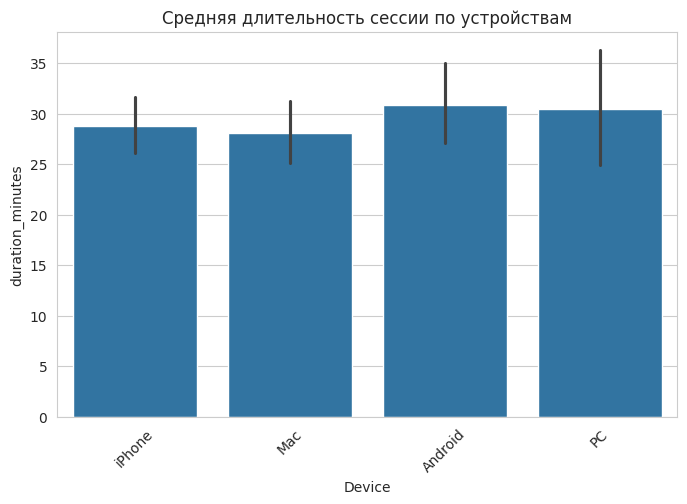

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(x='Device', y='duration_minutes', data=df, estimator='mean')

plt.title('Средняя длительность сессии по устройствам')
plt.xticks(rotation=45)
plt.show()

На столбчатой диаграмме показана средняя длительность сессий для разных типов устройств. В целом значения близки друг к другу и находятся примерно в диапазоне 28–31 минуты.

Самая низкая средняя длительность наблюдается у пользователей `Mac`, немного выше — у `iPhone`. Наибольшие средние значения показывают `Android` и `PC`.

Главные различия заметны в разбросе данных, который отображается линиями ошибок. Для устройств `Apple` разброс небольшой, что говорит о более стабильном и предсказуемом поведении пользователей.

У `Android` и `PC` диапазон разброса значительно шире — около 10–12 минут. Это указывает на более разнообразные сценарии использования: среди пользователей встречаются как очень короткие, так и очень длинные сессии.

Таким образом, средняя длительность сессий у всех устройств примерно одинакова, но `Android` и `PC` отличаются большей вариативностью пользовательского поведения.

##Вывод:
По итогам работы выполнена полная очистка данных: устранены пропуски, дубликаты и несогласованности в названиях, а также исправлены типы данных для столбцов с датой и временем.

